In [ ]:
import pandas as pd

# Example: Load your data from a CSV file
# Replace 'your_file.csv' with your actual file path
# Ensure the file has 4 columns of corresponding data
mycsv = r"C:\Users\Adam\Box\WaterTAP (protected by NDA)\nawi 1.0 (NDA protected)\WaterTAP-5.09 MF-RO-UV\data\UCI_Pilot\pump_surrogate_models\pump_data\multispeed_ro_pump_head_power_concatenated_global_normalized.csv"

df = pd.read_csv(mycsv)

# Display original data
print("Original Data:")
print(df)

# Interpolate missing values (NaN) using linear interpolation
# This will handle gaps in all columns while preserving alignment
df_interpolated = df.interpolate(method='linear', limit_direction='forward', axis=0)

# Display interpolated data
print("\nInterpolated Data:")
print(df_interpolated)

# Optionally, save the result to a new CSV file

Original Data:
     Flowrate_norm_global  Head_norm_global  Power_norm_global  Speed_norm
0                0.000000          0.175085           0.000000         0.5
1                0.000000          0.175085           0.000000         0.5
2                0.000000          0.296073           0.068702         0.6
3                0.000000          0.296073           0.068702         0.6
4                0.000000          0.439058           0.164583         0.7
..                    ...               ...                ...         ...
475              0.952645          0.366257                NaN         1.0
476              0.974785               NaN           0.966708         1.0
477              0.976396          0.333324                NaN         1.0
478              1.000000               NaN           1.000000         1.0
479              1.000000          0.299659                NaN         1.0

[480 rows x 4 columns]

Interpolated Data:
     Flowrate_norm_global  Head_norm_glob

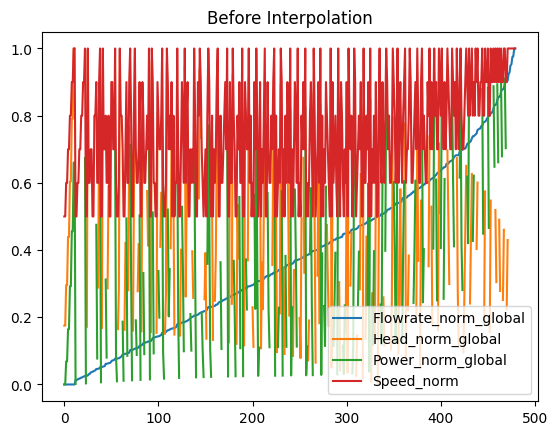

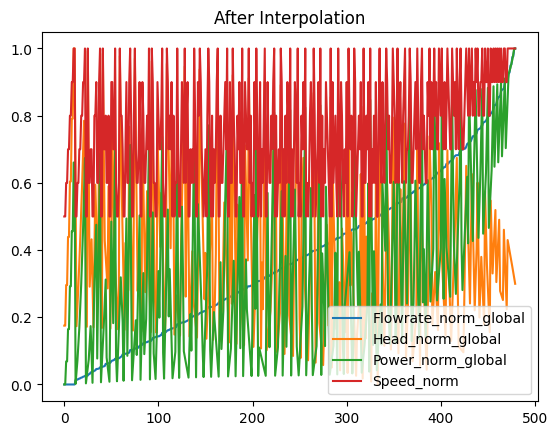

In [ ]:

import matplotlib.pyplot as plt

df.plot(title='Before Interpolation')
df_interpolated.plot(title='After Interpolation')
plt.show()




In [ ]:

import matplotlib.pyplot as plt

df.scatter(title='Before Interpolation')
df_interpolated.scatter(title='After Interpolation')

plt.show()




AttributeError: 'DataFrame' object has no attribute 'scatter'

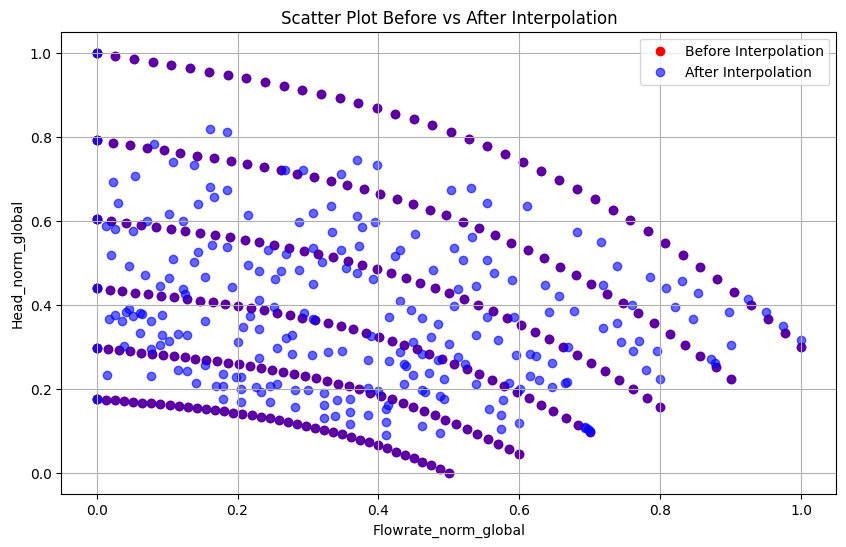

In [ ]:

# Scatter plot before interpolation
plt.figure(figsize=(10, 6))
plt.scatter(df['Flowrate_norm_global'], df['Head_norm_global'], color='red', label='Before Interpolation')
plt.scatter(df_interpolated['Flowrate_norm_global'], df_interpolated['Head_norm_global'], color='blue', alpha=0.6, label='After Interpolation')
plt.xlabel('Flowrate_norm_global')
plt.ylabel('Head_norm_global')
plt.title('Scatter Plot Before vs After Interpolation')
plt.legend()
plt.grid(True)
plt.show()




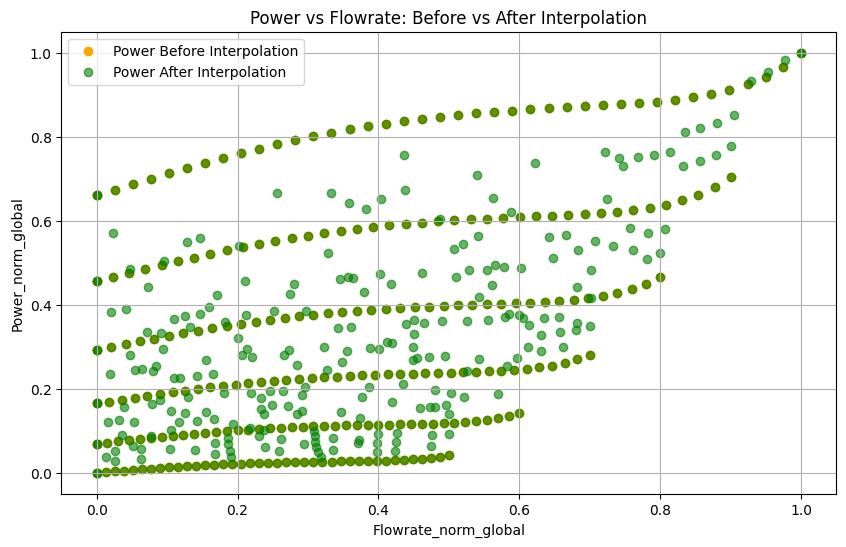

In [ ]:

# Scatter plot for Power vs Flowrate
plt.figure(figsize=(10, 6))
plt.scatter(df['Flowrate_norm_global'], df['Power_norm_global'], color='orange', label='Power Before Interpolation')
plt.scatter(df_interpolated['Flowrate_norm_global'], df_interpolated['Power_norm_global'], color='green', alpha=0.6, label='Power After Interpolation')
plt.xlabel('Flowrate_norm_global')
plt.ylabel('Power_norm_global')
plt.title('Power vs Flowrate: Before vs After Interpolation')
plt.legend()
plt.grid(True)
plt.show()



In [ ]:

# Prepare grid for contour plot
x = df_interpolated['Flowrate_norm_global'].values
y = df_interpolated['Power_norm_global'].values
z_head = df_interpolated['Head_norm_global'].values
z_speed = df_interpolated['Speed_norm'].values

# Create grid
xi = np.linspace(min(x), max(x), 100)
yi = np.linspace(min(y), max(y), 100)
Xi, Yi = np.meshgrid(xi, yi)

# Interpolate z values on grid
Zi_head = griddata((x, y), z_head, (Xi, Yi), method='cubic')
Zi_speed = griddata((x, y), z_speed, (Xi, Yi), method='cubic')

# Plot contourf for Head and contour lines for Speed
plt.figure(figsize=(8, 6))
contourf = plt.contourf(Xi, Yi, Zi_head, levels=20, cmap='viridis')
plt.colorbar(contourf, label='Head_norm_global')

# Add Speed contours
speed_contours = plt.contour(Xi, Yi, Zi_speed, levels=10, colors='white', linewidths=1)
plt.clabel(speed_contours, inline=True, fontsize=8, fmt='Speed: %.2f')

# Scatter original points
plt.scatter(x, y, color='red', s=20, label='Data Points')
plt.xlabel('Flowrate_norm_global')
plt.ylabel('Power_norm_global')
plt.title('Contourf Plot: Head (filled) and Speed (line contours) over Flowrate vs Power')
plt.legend()
plt.grid(True)
plt.show()


NameError: name 'np' is not defined

In [ ]:
import numpy as np

In [ ]:

# Prepare grid for contour plot
x = df_interpolated['Flowrate_norm_global'].values
y = df_interpolated['Power_norm_global'].values
z_head = df_interpolated['Head_norm_global'].values
z_speed = df_interpolated['Speed_norm'].values

# Create grid
xi = np.linspace(min(x), max(x), 100)
yi = np.linspace(min(y), max(y), 100)
Xi, Yi = np.meshgrid(xi, yi)

# Interpolate z values on grid
Zi_head = griddata((x, y), z_head, (Xi, Yi), method='cubic')
Zi_speed = griddata((x, y), z_speed, (Xi, Yi), method='cubic')

# Plot contourf for Head and contour lines for Speed
plt.figure(figsize=(8, 6))
contourf = plt.contourf(Xi, Yi, Zi_head, levels=20, cmap='viridis')
plt.colorbar(contourf, label='Head_norm_global')

# Add Speed contours
speed_contours = plt.contour(Xi, Yi, Zi_speed, levels=10, colors='white', linewidths=1)
plt.clabel(speed_contours, inline=True, fontsize=8, fmt='Speed: %.2f')

# Scatter original points
plt.scatter(x, y, color='red', s=20, label='Data Points')
plt.xlabel('Flowrate_norm_global')
plt.ylabel('Power_norm_global')
plt.title('Contourf Plot: Head (filled) and Speed (line contours) over Flowrate vs Power')
plt.legend()
plt.grid(True)
plt.show()



NameError: name 'griddata' is not defined

In [ ]:

from scipy.interpolate import griddata



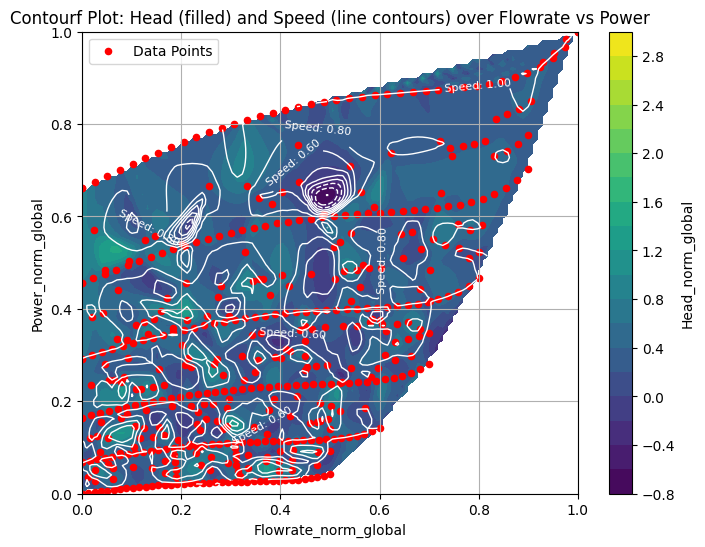

In [ ]:

# Prepare grid for contour plot
x = df_interpolated['Flowrate_norm_global'].values
y = df_interpolated['Power_norm_global'].values
z_head = df_interpolated['Head_norm_global'].values
z_speed = df_interpolated['Speed_norm'].values

# Create grid
xi = np.linspace(min(x), max(x), 100)
yi = np.linspace(min(y), max(y), 100)
Xi, Yi = np.meshgrid(xi, yi)

# Interpolate z values on grid
Zi_head = griddata((x, y), z_head, (Xi, Yi), method='cubic')
Zi_speed = griddata((x, y), z_speed, (Xi, Yi), method='cubic')

# Plot contourf for Head and contour lines for Speed
plt.figure(figsize=(8, 6))
contourf = plt.contourf(Xi, Yi, Zi_head, levels=20, cmap='viridis')
plt.colorbar(contourf, label='Head_norm_global')

# Add Speed contours
speed_contours = plt.contour(Xi, Yi, Zi_speed, levels=10, colors='white', linewidths=1)
plt.clabel(speed_contours, inline=True, fontsize=8, fmt='Speed: %.2f')

# Scatter original points
plt.scatter(x, y, color='red', s=20, label='Data Points')
plt.xlabel('Flowrate_norm_global')
plt.ylabel('Power_norm_global')
plt.title('Contourf Plot: Head (filled) and Speed (line contours) over Flowrate vs Power')
plt.legend()
plt.grid(True)
plt.show()



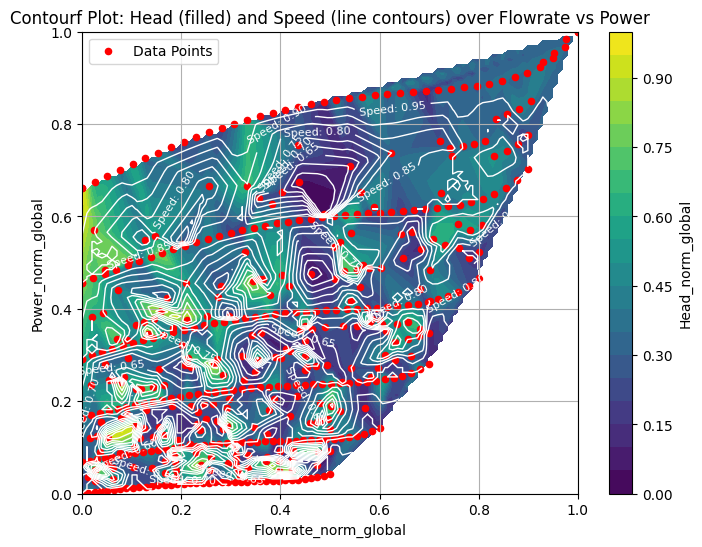

In [ ]:

# Prepare grid for contour plot
x = df_interpolated['Flowrate_norm_global'].values
y = df_interpolated['Power_norm_global'].values
z_head = df_interpolated['Head_norm_global'].values
z_speed = df_interpolated['Speed_norm'].values

# Create grid
xi = np.linspace(min(x), max(x), 100)
yi = np.linspace(min(y), max(y), 100)
Xi, Yi = np.meshgrid(xi, yi)

# Interpolate z values on grid
Zi_head = griddata((x, y), z_head, (Xi, Yi), method='linear')
Zi_speed = griddata((x, y), z_speed, (Xi, Yi), method='linear')

# Plot contourf for Head and contour lines for Speed
plt.figure(figsize=(8, 6))
contourf = plt.contourf(Xi, Yi, Zi_head, levels=20, cmap='viridis')
plt.colorbar(contourf, label='Head_norm_global')

# Add Speed contours
speed_contours = plt.contour(Xi, Yi, Zi_speed, levels=10, colors='white', linewidths=1)
plt.clabel(speed_contours, inline=True, fontsize=8, fmt='Speed: %.2f')

# Scatter original points
plt.scatter(x, y, color='red', s=20, label='Data Points')
plt.xlabel('Flowrate_norm_global')
plt.ylabel('Power_norm_global')
plt.title('Contourf Plot: Head (filled) and Speed (line contours) over Flowrate vs Power')
plt.legend()
plt.grid(True)
plt.show()



In [ ]:

df_interpolated.to_csv('interpolated_output.csv', index=False)



In [ ]:

df = df.apply(pd.to_numeric, errors='coerce')

# Sort by Speed and Flowrate
df = df.sort_values(['Speed_norm', 'Flowrate_norm_global'])

# Interpolate within each Speed group
df_interpolated = df.groupby('Speed_norm').apply(lambda g: g.interpolate(method='linear')).reset_index(drop=True)

# Export corrected interpolation
df_interpolated.to_csv('interpolated_by_speed.csv', index=False)



<ipython-input-13-f2bdf16df47f>:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_interpolated = df.groupby('Speed_norm').apply(lambda g: g.interpolate(method='linear')).reset_index(drop=True)


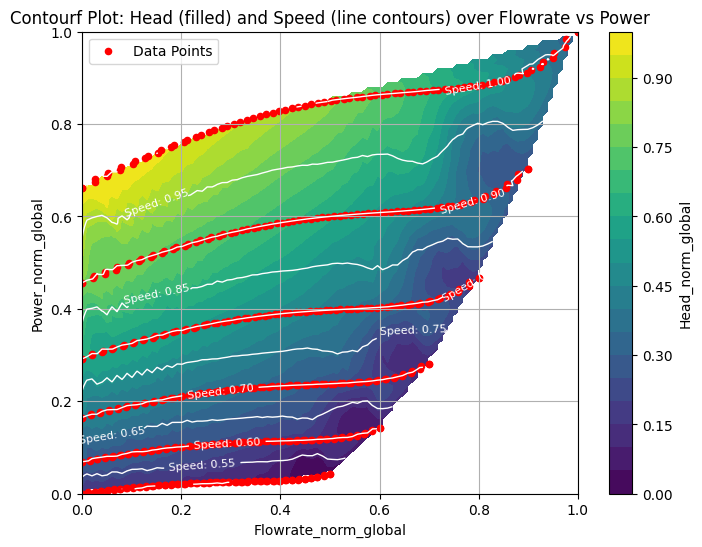

In [ ]:

# Prepare grid for contour plot
x = df_interpolated['Flowrate_norm_global'].values
y = df_interpolated['Power_norm_global'].values
z_head = df_interpolated['Head_norm_global'].values
z_speed = df_interpolated['Speed_norm'].values

# Create grid
xi = np.linspace(min(x), max(x), 100)
yi = np.linspace(min(y), max(y), 100)
Xi, Yi = np.meshgrid(xi, yi)

# Interpolate z values on grid
Zi_head = griddata((x, y), z_head, (Xi, Yi), method='cubic')
Zi_speed = griddata((x, y), z_speed, (Xi, Yi), method='cubic')

# Plot contourf for Head and contour lines for Speed
plt.figure(figsize=(8, 6))
contourf = plt.contourf(Xi, Yi, Zi_head, levels=20, cmap='viridis')
plt.colorbar(contourf, label='Head_norm_global')

# Add Speed contours
speed_contours = plt.contour(Xi, Yi, Zi_speed, levels=10, colors='white', linewidths=1)
plt.clabel(speed_contours, inline=True, fontsize=8, fmt='Speed: %.2f')

# Scatter original points
plt.scatter(x, y, color='red', s=20, label='Data Points')
plt.xlabel('Flowrate_norm_global')
plt.ylabel('Power_norm_global')
plt.title('Contourf Plot: Head (filled) and Speed (line contours) over Flowrate vs Power')
plt.legend()
plt.grid(True)
plt.show()



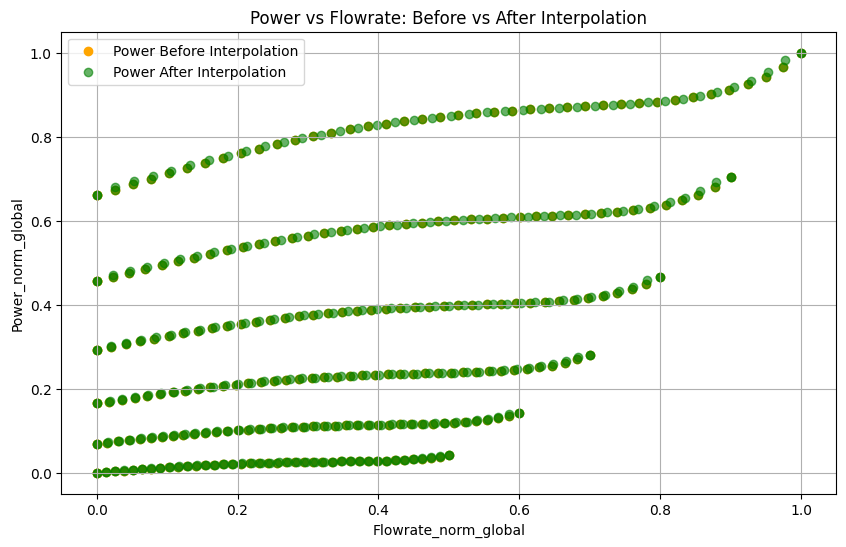

In [ ]:

# Scatter plot for Power vs Flowrate
plt.figure(figsize=(10, 6))
plt.scatter(df['Flowrate_norm_global'], df['Power_norm_global'], color='orange', label='Power Before Interpolation')
plt.scatter(df_interpolated['Flowrate_norm_global'], df_interpolated['Power_norm_global'], color='green', alpha=0.6, label='Power After Interpolation')
plt.xlabel('Flowrate_norm_global')
plt.ylabel('Power_norm_global')
plt.title('Power vs Flowrate: Before vs After Interpolation')
plt.legend()
plt.grid(True)
plt.show()



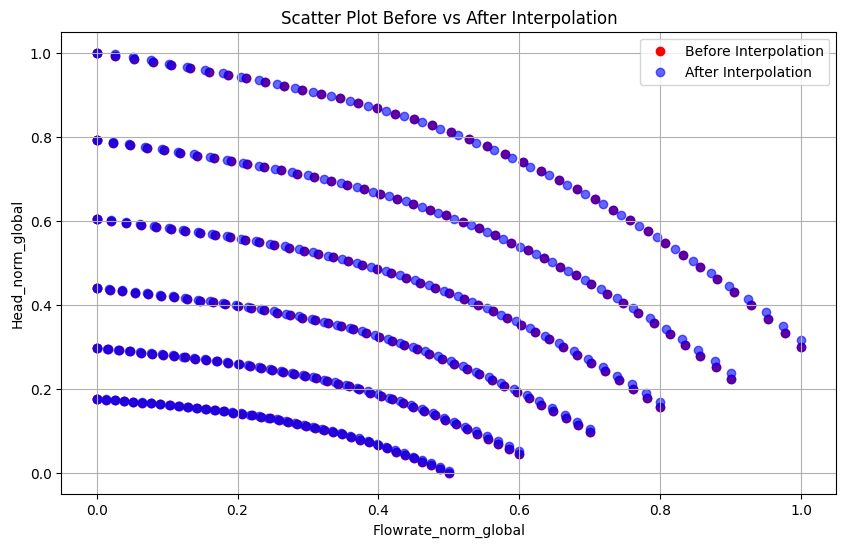

In [ ]:

# Scatter plot before interpolation
plt.figure(figsize=(10, 6))
plt.scatter(df['Flowrate_norm_global'], df['Head_norm_global'], color='red', label='Before Interpolation')
plt.scatter(df_interpolated['Flowrate_norm_global'], df_interpolated['Head_norm_global'], color='blue', alpha=0.6, label='After Interpolation')
plt.xlabel('Flowrate_norm_global')
plt.ylabel('Head_norm_global')
plt.title('Scatter Plot Before vs After Interpolation')
plt.legend()
plt.grid(True)
plt.show()




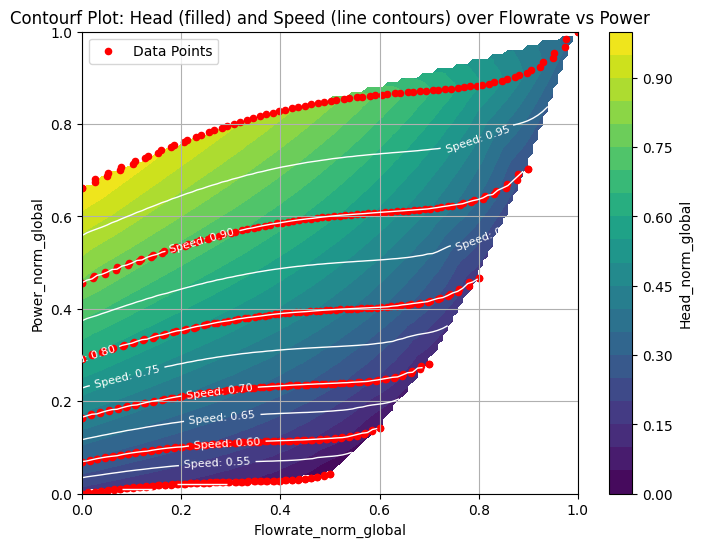

In [ ]:

# Prepare grid for contour plot
x = df_interpolated['Flowrate_norm_global'].values
y = df_interpolated['Power_norm_global'].values
z_head = df_interpolated['Head_norm_global'].values
z_speed = df_interpolated['Speed_norm'].values

# Create grid
xi = np.linspace(min(x), max(x), 100)
yi = np.linspace(min(y), max(y), 100)
Xi, Yi = np.meshgrid(xi, yi)

# Interpolate z values on grid
Zi_head = griddata((x, y), z_head, (Xi, Yi), method='linear')
Zi_speed = griddata((x, y), z_speed, (Xi, Yi), method='linear')

# Plot contourf for Head and contour lines for Speed
plt.figure(figsize=(8, 6))
contourf = plt.contourf(Xi, Yi, Zi_head, levels=20, cmap='viridis')
plt.colorbar(contourf, label='Head_norm_global')

# Add Speed contours
speed_contours = plt.contour(Xi, Yi, Zi_speed, levels=10, colors='white', linewidths=1)
plt.clabel(speed_contours, inline=True, fontsize=8, fmt='Speed: %.2f')

# Scatter original points
plt.scatter(x, y, color='red', s=20, label='Data Points')
plt.xlabel('Flowrate_norm_global')
plt.ylabel('Power_norm_global')
plt.title('Contourf Plot: Head (filled) and Speed (line contours) over Flowrate vs Power')
plt.legend()
plt.grid(True)
plt.show()

